In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sys
import os
import xarray as xr
import cartopy.crs as ccrs



In [3]:
# import storm dataset
from pathlib import Path


# add project root (parent of Notebooks/) to sys.path
root = Path.cwd().parent
if str(root) not in sys.path:
    sys.path.insert(0, str(root))



# Import storm dataset and related modules
from functions.storm_dataset import storm_tracking_event, continuos_storm, storm_tracking_features
from functions.storm_direction import mean_precipitation_within_ellipse, get_max_accumulated_value, compute_line_length, mean_velocity, mean_direction, mean_direction_ln, mean_direction_weighted
from functions.diagnostic_plots import diagnostic_plot_storm_trajectories, plot_storm_track, plot_storm_time_steps

In [4]:
# Set the SST catalog folder path
folder = '/Users/diegoosorio/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/RainyDay_Runs/Run_CONUS/Results/Domain_86.0_circle_10000km2/StormCatalog'
event_list = os.listdir(folder)
event_list = [event for event in event_list if event.endswith('.nc')]

In [5]:
##Run of storm tracking for specif event
n_storm = '_94' # storm number
name = [s for s in event_list if str(n_storm) in s][0] # find the storm name
#name = 'IOWA_Domain.nc_storm_27_20210324.nc'
event_dict = {}
ds = xr.open_dataset(os.path.join(folder, name))
print(name)
storm_tracking_event(ds, event_dict, morph_radius=4, high_threshold=1)
continuos_storm(event_dict)
storm_tracking_features(event_dict)

IOWA_Domain.nc_storm_94_20140808.nc
The longest storm has a valid duration of 16 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2014-08-09T05:00:00.000000000 to 2014-08-09T20:00:00.000000000
Selected storm duration 16 hours


{'storm_pcrp': <xarray.Variable (time: 24, latitude: 150, longitude: 150)> Size: 2MB
 array([[[ 8.750e-01,  6.250e-01, ..., -9.999e+03, -9.999e+03],
         [ 1.000e+00,  8.125e-01, ..., -9.999e+03, -9.999e+03],
         ...,
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00],
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00]],
 
        [[ 0.000e+00,  0.000e+00, ..., -9.999e+03, -9.999e+03],
         [ 0.000e+00,  0.000e+00, ..., -9.999e+03, -9.999e+03],
         ...,
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00],
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00]],
 
        ...,
 
        [[ 0.000e+00,  0.000e+00, ..., -9.999e+03, -9.999e+03],
         [ 0.000e+00,  0.000e+00, ..., -9.999e+03, -9.999e+03],
         ...,
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00],
         [ 0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00]],
 
        [[ 0.000e+00,  0.000e+00, ..., -9.999e+03, -9.999e+03],
         [ 0.000e

In [6]:
def fit_ellipse_to_rainfall(rainfall_field, x_coords, y_coords, threshold=1.0):
    """
    Fits an ellipse to a 2D rainfall field using the method of moments.

    Args:
        rainfall_field (np.ndarray): A 2D NumPy array where each value is the
                                    rainfall intensity.
        threshold (float): The minimum rainfall intensity to consider.
                           Values below this will be set to zero.

    Returns:
        dict: A dictionary containing the ellipse parameters:
              'center' (tuple), 'major_axis' (float), 'minor_axis' (float),
              'angle_deg' (float). Returns None if no data is above the threshold.
    """
    # Ensure input is a numpy array
    field = np.array(rainfall_field)
    
    # Apply threshold
    field_thresholded = np.where(field >= threshold, field, 0)

    

    # Calculate zeroth moment (total intensity)
    m00 = np.sum(field_thresholded)

    # Check if there is any rainfall above the threshold
    if m00 == 0:
        return None

    # First moments (to find the centroid)
    m10 = np.sum(x_coords * field_thresholded)
    m01 = np.sum(y_coords * field_thresholded)

    # --- Step 2: Calculate Ellipse Center (Centroid) ---
    x_bar = m10 / m00
    y_bar = m01 / m00

    # Second central moments (to find size and orientation)
    mu20 = np.sum((x_coords - x_bar)**2 * field) / m00
    mu02 = np.sum((y_coords - y_bar)**2 * field) / m00
    mu11 = np.sum((x_coords - x_bar) * (y_coords - y_bar) * field) / m00

    # --- Step 3: Calculate Ellipse Axes and Angle ---
    # Common term
    common_term = np.sqrt((mu20 - mu02)**2 + 4 * mu11**2)

    # Major and minor axes (proportional to standard deviations)
    # The factor 2*sqrt(2) scales the ellipse to contain ~86.5% of the total intensity
    # under a Gaussian assumption, a common convention.
    major_axis = 2 * np.sqrt(2) * np.sqrt(0.5 * ((mu20 + mu02) + common_term))
    minor_axis = 2 * np.sqrt(2) * np.sqrt(0.5 * ((mu20 + mu02) - common_term))

    # Orientation angle
    angle_rad = 0.5 * np.arctan2(2 * mu11, mu20 - mu02)
    angle_deg = np.degrees(angle_rad)

    return {
        'center': (x_bar, y_bar),
        'major_axis': major_axis,
        'minor_axis': minor_axis,
        'angle_deg': angle_deg
    }

In [129]:
event_dict['storm_time']

<xarray.DataArray 'time' (time: 24)> Size: 192B
array(['2011-09-06T00:00:00.000000000', '2011-09-06T01:00:00.000000000',
       '2011-09-06T02:00:00.000000000', '2011-09-06T03:00:00.000000000',
       '2011-09-06T04:00:00.000000000', '2011-09-06T05:00:00.000000000',
       '2011-09-06T06:00:00.000000000', '2011-09-06T07:00:00.000000000',
       '2011-09-06T08:00:00.000000000', '2011-09-06T09:00:00.000000000',
       '2011-09-06T10:00:00.000000000', '2011-09-06T11:00:00.000000000',
       '2011-09-06T12:00:00.000000000', '2011-09-06T13:00:00.000000000',
       '2011-09-06T14:00:00.000000000', '2011-09-06T15:00:00.000000000',
       '2011-09-06T16:00:00.000000000', '2011-09-06T17:00:00.000000000',
       '2011-09-06T18:00:00.000000000', '2011-09-06T19:00:00.000000000',
       '2011-09-06T20:00:00.000000000', '2011-09-06T21:00:00.000000000',
       '2011-09-06T22:00:00.000000000', '2011-09-06T23:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 192B 2011-09-06 ... 2011-09-06T23:00:00

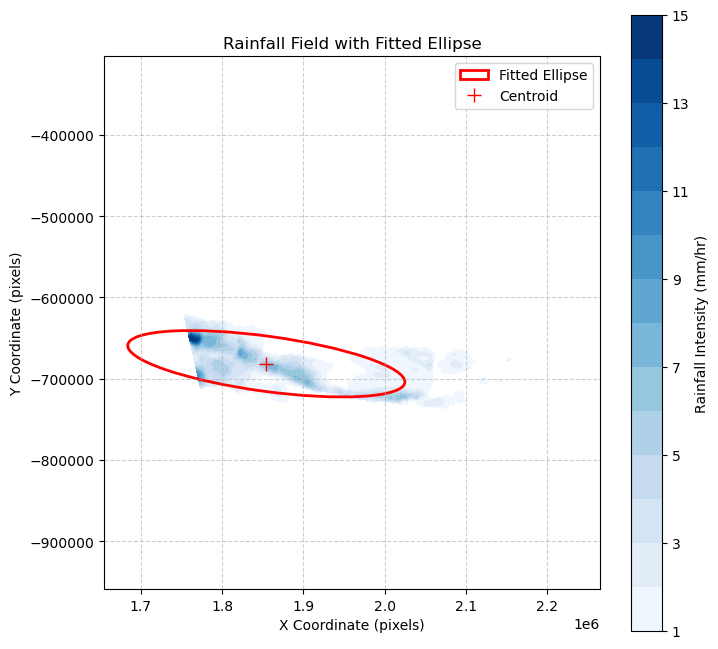

In [7]:
rainfall_data = event_dict['selected_storm'][3]
x_coords, y_coords = event_dict['lon_prj_array'], event_dict['lat_prj_array']
precipitation_threshold = np.quantile(rainfall_data[rainfall_data!=0].flatten(), q = 0.5)
ellipse_params = fit_ellipse_to_rainfall(rainfall_data, x_coords, y_coords,  threshold=precipitation_threshold)
# Create the plot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
nx, ny = x_coords, y_coords

# Plot the rainfall field
masked_data = np.where(rainfall_data < 0.1,np.nan, rainfall_data)
c = ax.contourf(x_coords, y_coords, masked_data, cmap='Blues', levels=15)
fig.colorbar(c, ax=ax, label='Rainfall Intensity (mm/hr)')

# Create the ellipse patch
ellipse = Ellipse(
    xy=ellipse_params['center'],
    width=ellipse_params['major_axis'],
    height=ellipse_params['minor_axis'],
    angle=ellipse_params['angle_deg'],
    edgecolor='r',
    facecolor='none',
    linewidth=2,
    label='Fitted Ellipse'
)
ax.add_patch(ellipse)

# Plot the centroid
ax.plot(ellipse_params['center'][0], ellipse_params['center'][1], 'r+', markersize=10, label='Centroid')

ax.set_title('Rainfall Field with Fitted Ellipse')
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [26]:
ellipse_params['angle_deg']

np.float64(59.80807776630189)

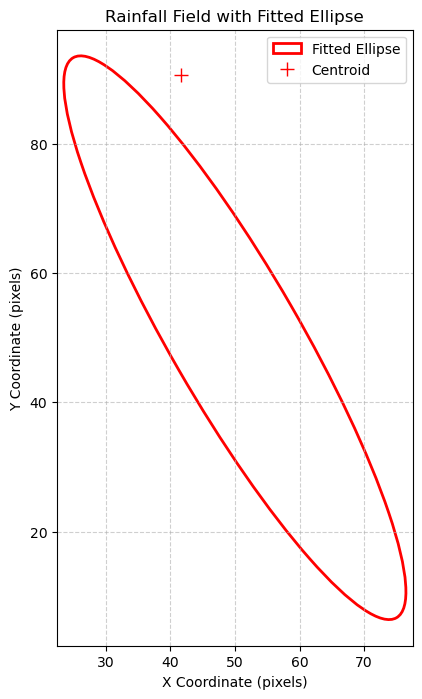

In [12]:
# Create the ellipse patch
ellipse = Ellipse(
    xy=(50, 50),
    width=100,
    height=20,
    angle=120,
    edgecolor='r',
    facecolor='none',
    linewidth=2,
    label='Fitted Ellipse'
)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.add_patch(ellipse)

# Plot the centroid
ax.plot(ellipse_params['center'][0], ellipse_params['center'][1], 'r+', markersize=10, label='Centroid')

ax.set_title('Rainfall Field with Fitted Ellipse')
ax.set_xlabel('X Coordinate (pixels)')
ax.set_ylabel('Y Coordinate (pixels)')
ax.set_aspect('equal', 'box')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

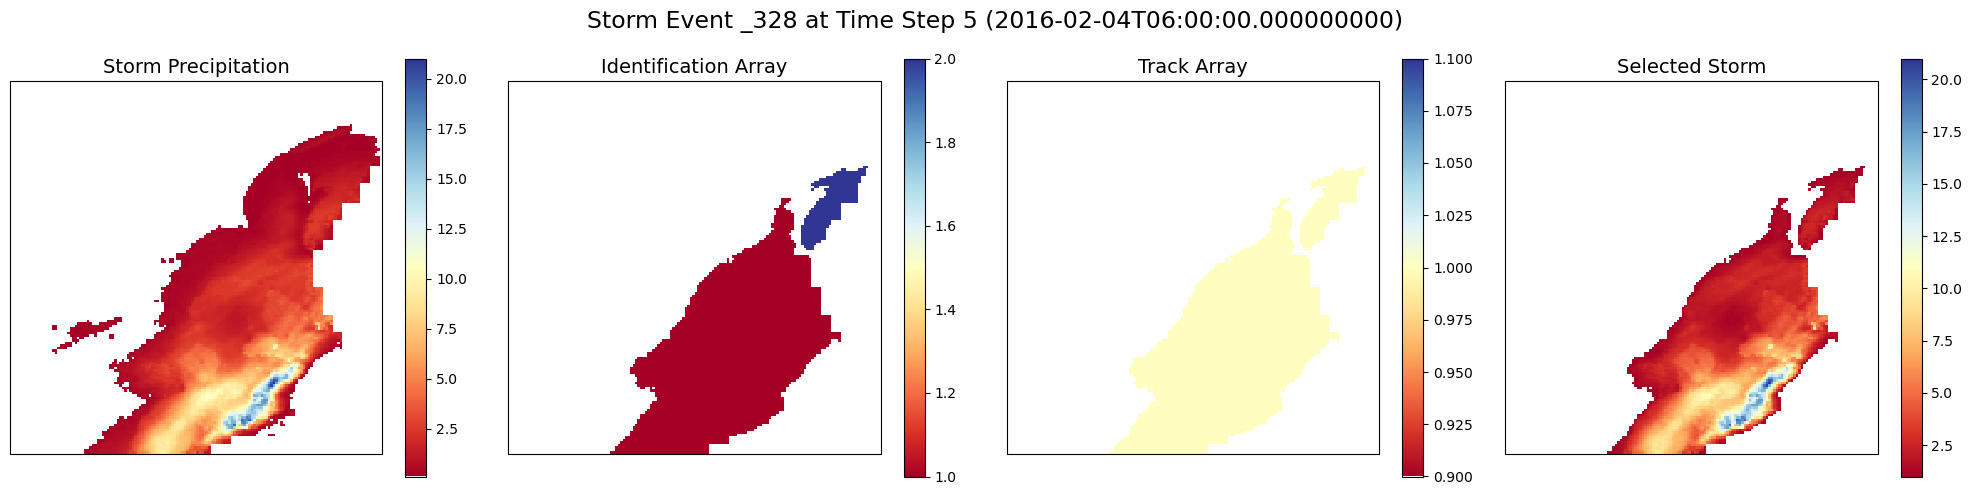

In [113]:
def plot_event_arrays(event_dict, time_step):
    """
    Plots the arrays in the event_dict at a given time step, masking 0 values.

    Parameters:
    - event_dict (dict): Dictionary containing arrays to plot.
    - time_step (int): Time step to plot.

    Arrays to plot:
    - storm_prcp
    - identification_array
    - track_array
    - selected_storm
    """
    arrays_to_plot = ['storm_pcrp', 'identification_array', 'track_array', 'selected_storm']
    titles = ['Storm Precipitation', 'Identification Array', 'Track Array', 'Selected Storm']

    a = event_dict['selected_storm_time_steps']
    b = event_dict['storm_time']
    matching_indices = np.where(np.isin(b.values, a.values))[0]
    storm_index = matching_indices[time_step]
    
    
    fig, axes = plt.subplots(1, len(arrays_to_plot), figsize=(20, 5), subplot_kw={'projection': ccrs.PlateCarree()})
    for i, array_name in enumerate(arrays_to_plot):
        if array_name == 'selected_storm':
            array = event_dict[array_name][time_step]
        else:
            array = event_dict[array_name][storm_index]
        masked_array = np.ma.masked_where(array <0.1, array)  # Mask 0 values
    
        rain = axes[i].pcolormesh(event_dict['lon_array'], event_dict['lat_array'], 
                             masked_array,
                             cmap='RdYlBu')
        axes[i].set_title(titles[i], fontsize=14)
        plt.colorbar(rain, ax=axes[i])
    plt.suptitle(f'Storm Event {n_storm} at Time Step {time_step} ({a[time_step].values})', fontsize=17)
    plt.tight_layout()
    plt.show()

# Example usage:
plot_event_arrays(event_dict, time_step=5)